<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet/blob/yasaswita/notebooks/CICIDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE


In [34]:
from google.colab import files
uploaded = files.upload()



Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX (1).csv


In [35]:
#Load dataset
df = pd.read_csv('/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

print("Shape:", df.shape)
print(df.head())


Shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                           

In [36]:

drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=drop_cols, errors='ignore')

df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

print("After cleaning:", df.shape)


After cleaning: (225745, 79)


In [37]:
# Replace infinite values & fill NaN
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

print("Shape after cleaning:", df.shape)

# Data Profiling / Visualization
print(df.info())
print(df.describe())
print("Missing values per column:\n", df.isnull().sum())


Shape after cleaning: (225745, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Pack

In [38]:
#Label Encoding
df['attack_binary'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print(df['attack_binary'].value_counts())

attack_binary
1    128027
0     97718
Name: count, dtype: int64


/tmp/ipython-input-2594658914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=df, palette='Set2')


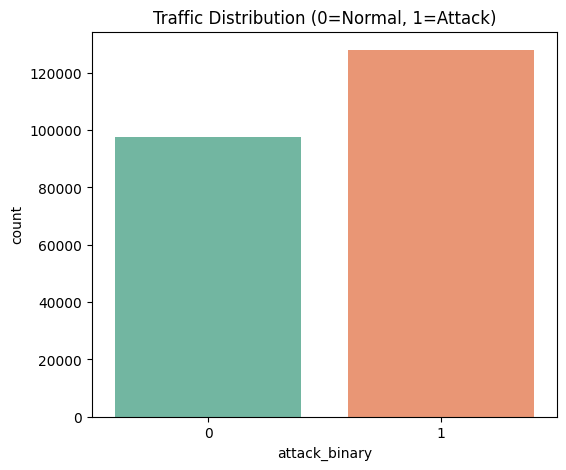

/tmp/ipython-input-2594658914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=' Label', data=attack_df, order=attack_df[' Label'].value_counts().index, palette='viridis')


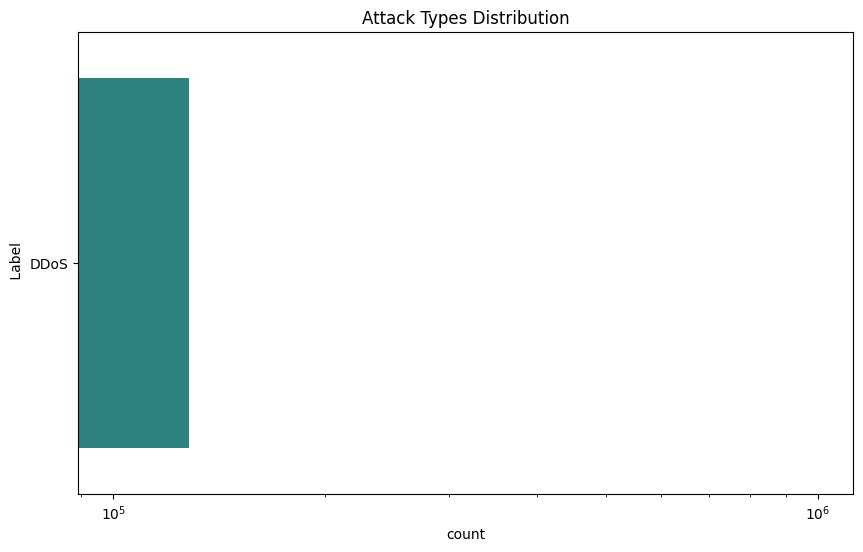

In [39]:
#Distributions
plt.figure(figsize=(6,5))
sns.countplot(x='attack_binary', data=df, palette='Set2')
plt.title("Traffic Distribution (0=Normal, 1=Attack)")
plt.show()

attack_df = df[df['attack_binary'] == 1]
plt.figure(figsize=(10,6))
sns.countplot(y=' Label', data=attack_df, order=attack_df[' Label'].value_counts().index, palette='viridis')
plt.title("Attack Types Distribution")
plt.xscale('log')
plt.show()

In [40]:
# Identify categorical and numerical features
X = df.drop([' Label', 'attack_binary'], axis=1)
y = df['attack_binary']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

print("Categorical columns:", categorical_cols)
print("Number of numerical columns:", len(numerical_cols))



Categorical columns: Index([], dtype='object')
Number of numerical columns: 78


In [41]:
#One-Hot Encode categorical
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X.shape)


Shape after encoding: (225745, 78)


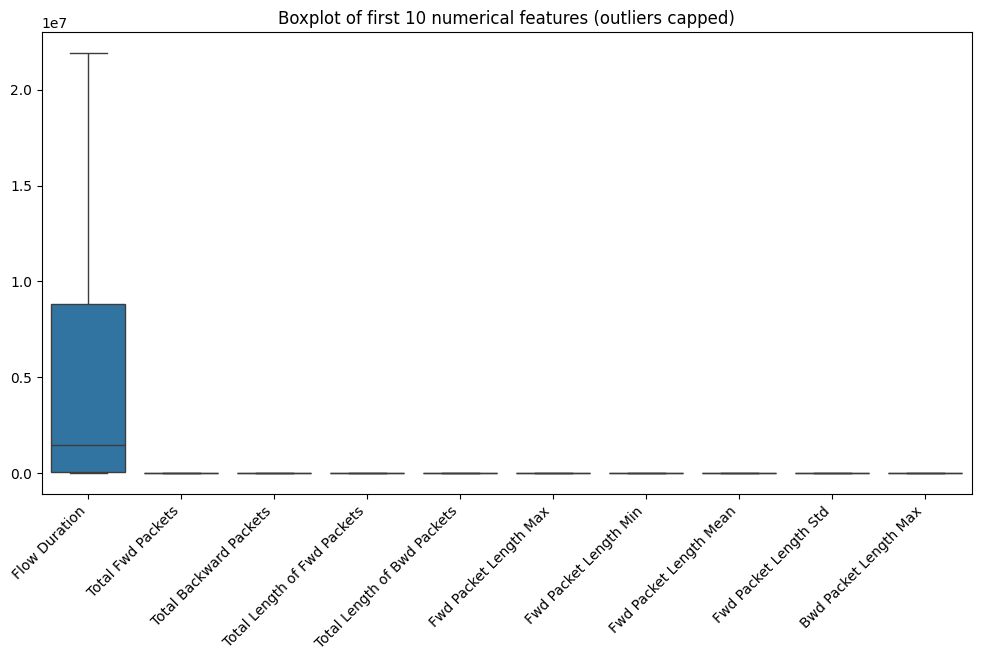

In [54]:
#Handle Outliers (IQR)
X.columns = X.columns.str.strip() # Strip spaces from all column names in the DataFrame
numerical_cols = X.select_dtypes(include=[np.number]).columns # Regenerate numerical_cols after stripping
for col in numerical_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    X[col] = np.where(X[col]<lower, lower, X[col])
    X[col] = np.where(X[col]>upper, upper, X[col])

plt.figure(figsize=(12,6))
sns.boxplot(data=X[numerical_cols[:10]])
plt.title("Boxplot of first 10 numerical features (outliers capped)")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.show()

In [52]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (180596, 60) (180596,)
Test shape: (45149, 60) (45149,)


Now that outliers have been handled, I will address the class imbalance in the training data using SMOTE (Synthetic Minority Over-sampling Technique) to create synthetic samples of the minority class. This helps improve the performance of the models, especially on the minority class.

After balancing the dataset, I'll visualize the feature correlations using a heatmap to understand the relationships between different features and identify potential multicollinearity.

In [ ]:
#Handle imbalance (SMOTE)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Original:", y_train.value_counts())
print("Resampled:", y_train_res.value_counts())

#Feature Correlation Visualization
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [44]:
#Feature Engineering
if ' Total Fwd Packets' in X.columns and ' Total Backward Packets' in X.columns:
    X['Total_Packets'] = X[' Total Fwd Packets'] + X[' Total Backward Packets']

if 'Total Length of Fwd Packets' in X.columns:
    X['Avg_Bytes_Per_Packet'] = X['Total Length of Fwd Packets'] / (X[' Total Fwd Packets'] + 1e-5)

In [32]:
# Update numerical_cols to include new features
numerical_cols = X_train.select_dtypes(include=[np.number]).columns

#Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaled training data head:")
display(X_train.head())



Scaled training data head:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Total_Packets,Avg_Bytes_Per_Packet
207214,0.0,-0.729679,-1.250889,-0.855251,-0.209077,-0.771722,0.562421,1.984210,0.847600,-0.797442,...,-0.615966,0.0,-0.615968,-0.616099,-0.643746,0.0,-0.643767,-0.653964,-1.250697,1.392718
92421,0.0,-0.523889,-0.415037,0.493188,-0.588076,1.158996,-0.277857,-0.805056,-0.519895,0.391839,...,-0.615966,0.0,-0.615968,-0.616099,-0.643746,0.0,-0.643767,-0.653964,0.106274,-0.357452
116240,0.0,-0.625022,-0.415037,0.493188,-0.588076,1.158996,-0.277857,-0.805056,-0.519895,0.391839,...,-0.615966,0.0,-0.615968,-0.616099,-0.643746,0.0,-0.643767,-0.653964,0.106274,-0.357452
126095,0.0,-0.730232,-0.415037,0.830297,-0.588076,1.158996,-0.277857,-0.805056,-0.519895,0.391839,...,-0.615966,0.0,-0.615968,-0.616099,-0.643746,0.0,-0.643767,-0.653964,0.332436,-0.357452
85923,0.0,-0.538373,-0.415037,0.493188,-0.588076,1.158996,-0.277857,-0.805056,-0.519895,0.391839,...,-0.615966,0.0,-0.615968,-0.616099,-0.643746,0.0,-0.643767,-0.653964,0.106274,-0.357452


In [45]:
# Data Reduction
selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(X)
X = pd.DataFrame(X_reduced, columns=X.columns[selector.get_support()])
print("Shape after low-variance feature removal:", X.shape)


Shape after low-variance feature removal: (225745, 60)


Original: attack_binary
1    102422
0     78174
Name: count, dtype: int64
Resampled: attack_binary
0    102422
1    102422
Name: count, dtype: int64


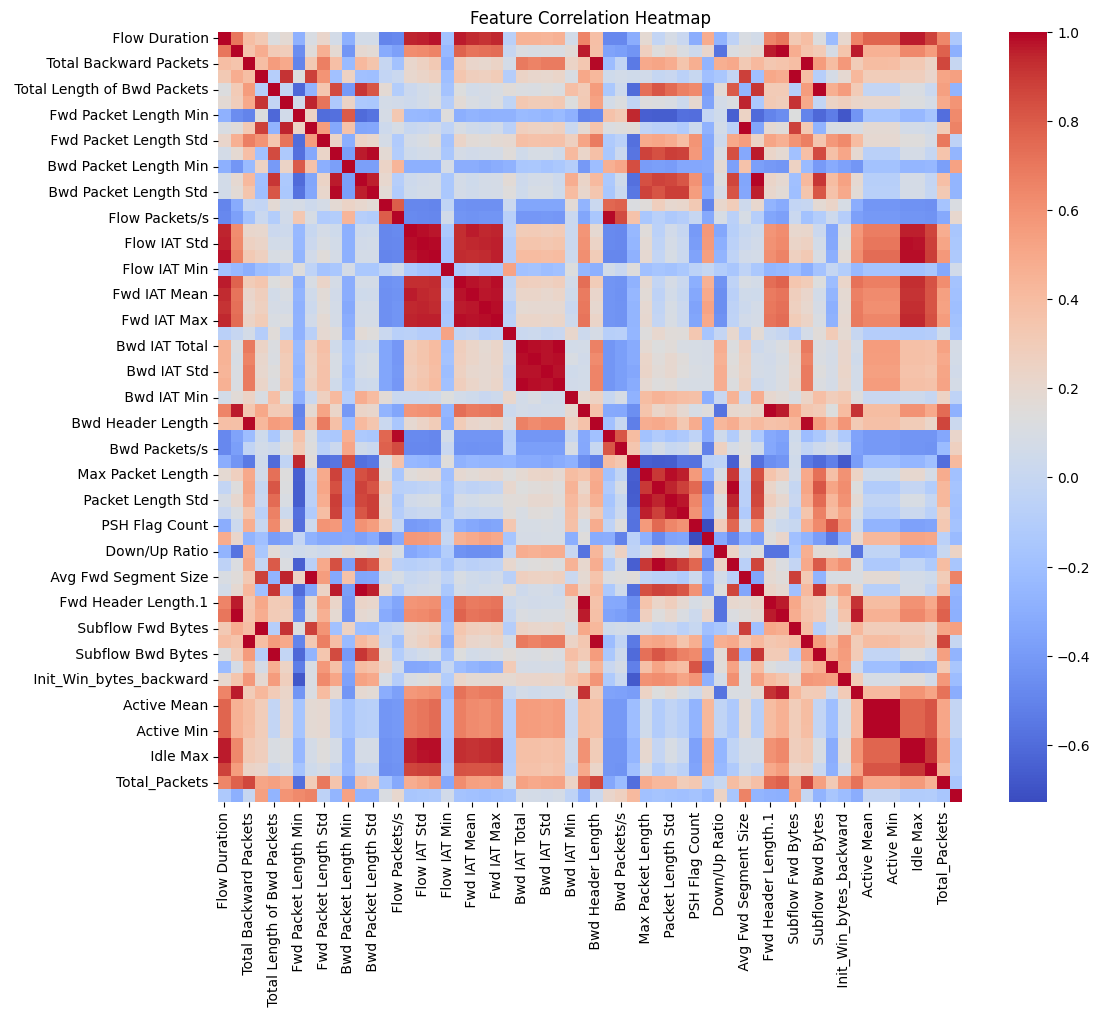

In [46]:
#Handle imbalance (SMOTE)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Original:", y_train.value_counts())
print("Resampled:", y_train_res.value_counts())

#Feature Correlation Visualization
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [31]:
#Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))
    print("="*50)


Training Logistic Regression...
Logistic Regression Accuracy: 99.90%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19544
      Attack       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Training Decision Tree...
Decision Tree Accuracy: 99.98%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19544
      Attack       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

Training Random Forest...
Random Forest Accuracy: 99.98%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19544
      Attack       1.00      1.00      1.00     25605


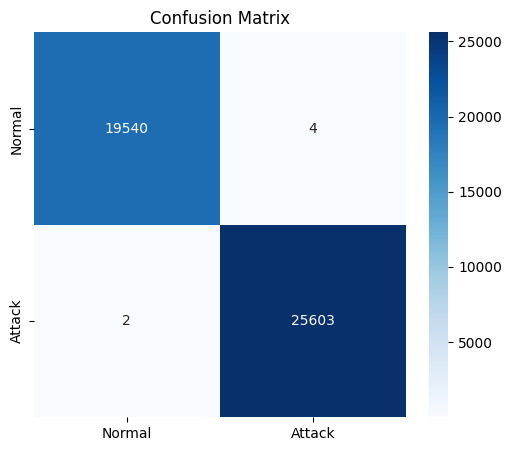

In [47]:
#Confusion Matrix
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train_res, y_train_res)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
plt.title("Confusion Matrix")
plt.show()
